# MEAPlotter Tutorial

End-to-end guide to producing publication figures from MEA activity/burst data.

**Flow:**  Setup → Quick plots → FDR-correct stats → Publication figure → Save PDF


## 0. Setup

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib, warnings
warnings.filterwarnings('ignore')

import meaplotter
importlib.reload(meaplotter)   # reload so edits to meaplotter.py take effect

# ── Data ──────────────────────────────────────────────────────────────────
CSV_PATH = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig2/ActivityScan_outputs/Compiled_Activity_Summary.csv'
df = pd.read_csv(CSV_PATH)
df['DIV']        = df['DIV'].astype(int)
df['NeuronType'] = df['NeuronType'].str.strip()
df['CHIP_WELL']  = df['Chip_ID'].astype(str) + '_' + df['Well'].astype(str)

# ── Experiment-level config ────────────────────────────────────────────────
GROUP_ORDER   = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE       = {'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}
SELECTED_DIVS = [13, 20, 27]   # mature timepoints — determines the FDR test family

# ── Instantiate — sets publication rcParams globally ──────────────────────
plotter = meaplotter.MEAPlotter(
    group_order=GROUP_ORDER,
    palette=PALETTE,
)

print(f'Loaded: {len(df)} rows | {df["CHIP_WELL"].nunique()} wells | '
      f'DIV {df["DIV"].min()}-{df["DIV"].max()}')
print('Genotypes:', df['NeuronType'].value_counts().to_dict())


Loaded: 152 rows | 19 wells | DIV 5-30
Genotypes: {'MxWT': 72, 'FxHET': 48, 'MxHEMI': 32}


## 1. `plot_bars` — quick single-timepoint overview

Use when you want to compare groups **collapsed across all DIVs** (or at a single DIV).
No significance annotation by default. Pass `annotate=True` to add ANOVA/Tukey brackets.

> **When NOT to use**: if your data spans multiple DIVs and you want to see development — use `plot_trajectory_with_dotplots` instead.


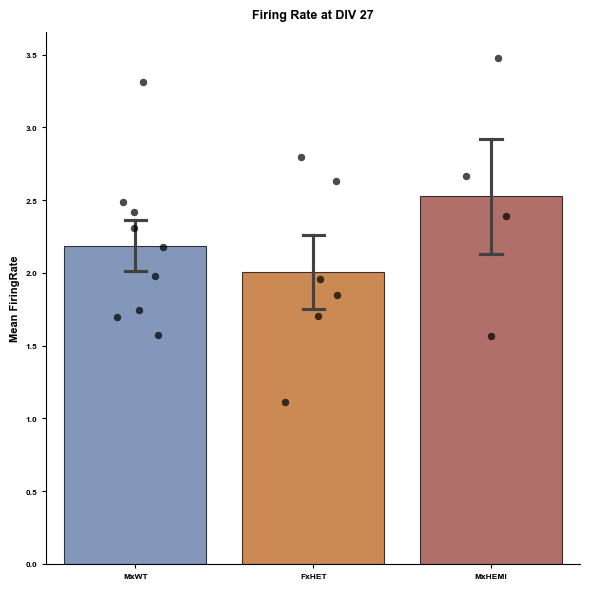

In [2]:
# Single timepoint example — filter to DIV 27 first
df_div27 = df[df['DIV'] == 27].copy()

ax = plotter.plot_bars(
    df_div27,
    x='NeuronType',
    y='Mean_FiringRate',
    title='Firing Rate at DIV 27',
    annotate=False,   # set True for ANOVA+Tukey brackets — but prefer FDR approach below
)
plt.tight_layout()
plt.show()


## 2. `plot_line_sem_by_div` — developmental trajectory

Mean ± SEM ribbon across all DIVs. Individual well scatter points with genotype offsets.
Upper outliers clipped at 98th percentile by default; shown as lollipop markers.

**Key parameters**
| param | default | effect |
|---|---|---|
| `clip_upper` | `True` | 98th-pct cap on y-axis |
| `scatter` | `True` | individual well points |
| `annotate` | `True` | auto-runs ANOVA stats — **pass `stats_df` from `calculate_stats_at_timepoints` instead** |
| `group_offset_width` | 0.25 | horizontal spread between genotype lines at each DIV |


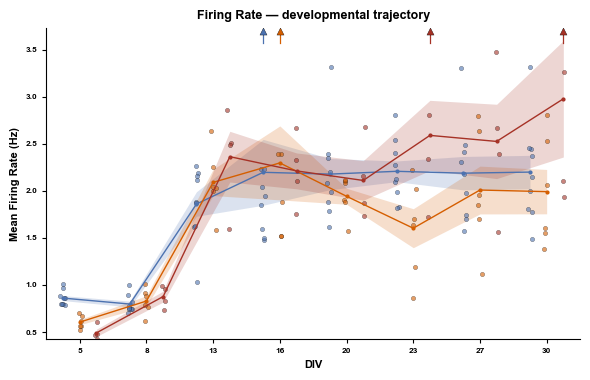

In [4]:
ax = plotter.plot_line_sem_by_div(
    df,
    div_col='DIV',
    group_col='NeuronType',
    y='Mean_FiringRate',
    ylabel='Mean Firing Rate (Hz)',
    title='Firing Rate — developmental trajectory',
    scatter=True,
    sem_alpha=0.20,
    clip_upper=True,
    clip_q=0.98,
    annotate=False,    # we compute FDR-corrected stats separately (Step 3)
    show_legend=False,  # we'll add a single legend for the whole figure at the end
    legend_outside=True,
    fig_width=6,
    aspect=0.65,
)
plt.tight_layout()
plt.show()


## 3. `calculate_stats_at_timepoints` — the right stats for MEA data

**Always use this, not `calculate_stats_by_div` or `calculate_stats_welch`.**

Why:  
- ANOVA assumes normality — MEA metrics (firing rate, burst count) are skewed.  
- Welch has no cross-timepoint correction — testing at 6+ DIVs inflates false positives.  

This function does:  
1. **Kruskal-Wallis** omnibus at each selected DIV (non-parametric).  
2. **Pairwise Wilcoxon** rank-sum post-hoc only where KW is significant.  
3. **BH-FDR** correction pooled across **all** (selected_div × pair) tests for this metric.  

Pass `selected_divs` = the mature timepoints only. Testing early noisy DIVs adds to the  
correction family and reduces power at the DIVs that matter.


In [5]:
stats_fr = plotter.calculate_stats_at_timepoints(
    df,
    div_col='DIV',
    group_col='NeuronType',
    y='Mean_FiringRate',
    selected_divs=SELECTED_DIVS,   # [13, 20, 27]
    group_order=GROUP_ORDER,
    min_n=3,                       # skip groups with fewer than 3 wells at that DIV
    alpha=0.05,
)

# The returned DataFrame has one row per (DIV, pair).
# Key columns: KW_p (omnibus), raw_p (Wilcoxon), q_val (BH-FDR), Sig, reject
cols_show = ['DIV', 'comparison', 'KW_p', 'raw_p', 'q_val', 'Sig', 'Grp1_Stats', 'Grp2_Stats']
print(stats_fr[cols_show].to_string(index=False))



==================== STATS (KW + Wilcoxon, BH-FDR): Mean_FiringRate ====================
Selected timepoints: [13, 20, 27]  min_n=3
  DIV 13: KW H=2.680 p=0.2619 → ns (no pairwise tests)
  DIV 20: KW H=0.877 p=0.6449 → ns (no pairwise tests)
  DIV 27: KW H=0.911 p=0.634 → ns (no pairwise tests)
 DIV      comparison     KW_p  raw_p  q_val Sig        Grp1_Stats        Grp2_Stats
  13 FxHET vs MxHEMI 0.261869    NaN    NaN  ns 2.09 ± 0.14 (n=6) 2.36 ± 0.27 (n=4)
  13   MxWT vs FxHET 0.261869    NaN    NaN  ns 1.86 ± 0.13 (n=9) 2.09 ± 0.14 (n=6)
  13  MxWT vs MxHEMI 0.261869    NaN    NaN  ns 1.86 ± 0.13 (n=9) 2.36 ± 0.27 (n=4)
  20 FxHET vs MxHEMI 0.644941    NaN    NaN  ns 1.94 ± 0.09 (n=6) 2.11 ± 0.21 (n=4)
  20   MxWT vs FxHET 0.644941    NaN    NaN  ns 2.18 ± 0.17 (n=9) 1.94 ± 0.09 (n=6)
  20  MxWT vs MxHEMI 0.644941    NaN    NaN  ns 2.18 ± 0.17 (n=9) 2.11 ± 0.21 (n=4)
  27 FxHET vs MxHEMI 0.634003    NaN    NaN  ns 2.01 ± 0.25 (n=6) 2.53 ± 0.39 (n=4)
  27   MxWT vs FxHET 0.634003  

## 4. `plot_trajectory_with_dotplots` — the publication figure

Two-row layout:
- **Row A**: full developmental trajectory (line + SEM ribbon).  
- **Row B/C/D**: one dot-plot per selected DIV, scatter + median + IQR bar.
  FDR-significant pairs shown as brackets (from the `stats_df` you computed above).

**Key sizing**
| use case | figsize | height_ratios |
|---|---|---|
| 1/3 column (journal) | `(3.0, 4.2)` | `(3, 2)` |
| half column | `(4.5, 5.5)` | `(3, 2)` |
| full A4 landscape | `(11.69, 8.27)` | `(3, 2)` |


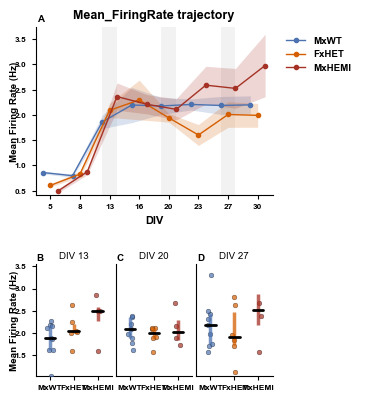

In [6]:
fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(
    df,
    div_col='DIV',
    group_col='NeuronType',
    y='Mean_FiringRate',
    selected_divs=SELECTED_DIVS,
    stats_df=stats_fr,         # FDR-corrected stats from Step 3
    group_order=GROUP_ORDER,
    palette=PALETTE,
    ylabel='Mean Firing Rate (Hz)',
    # ── figure size ──
    figsize=(3.0, 4.2),        # 1/3 column (76 mm × 107 mm)
    height_ratios=(3, 2),      # 60% trajectory / 40% dot plots
    # ── trajectory row ──
    traj_markers=True,         # dots on mean line at each DIV
    annotate_traj=False,       # no brackets on trajectory (clutters it)
    clip_upper=True,
    clip_q=0.98,
    # ── dot-plot row ──
    dot_size=12,
    scatter_jitter=0.12,
    show_xtick_labels=True,    # show genotype labels on x-axis
    # ── typography ──
    label_fontsize=7,
    tick_fontsize=6,
    panel_label_fontsize=7,
    legend_outside=True,
)
plt.show()


## 5. Loop over multiple metrics

Standard pattern for a figure panel with several metrics.  
Stats are computed **independently per metric** — FDR corrects within each metric's family.  
If you need to correct across metrics too, collect all p-values and run a second BH pass.


In [ ]:
METRICS = [
    ('Mean_FiringRate',    'Mean Firing Rate (Hz)'),
    ('Mean_SpikeAmplitude','Mean Spike Amplitude (uV)'),
    ('Active_area',        'Active Area (%)'),
]
SAVE_DIR = '/tmp/mea_tutorial/'  # change to your output folder
os.makedirs(SAVE_DIR, exist_ok=True)

all_stats = {}

for metric, ylabel in METRICS:
    if metric not in df.columns:
        print(f'Skipping {metric} — not in dataframe')
        continue

    # Step 1: FDR-corrected stats at mature DIVs
    stats = plotter.calculate_stats_at_timepoints(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
    )
    all_stats[metric] = stats

    # Step 2: Publication figure
    fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, stats_df=stats,
        group_order=GROUP_ORDER, palette=PALETTE, ylabel=ylabel,
        figsize=(3.0, 4.2), height_ratios=(3, 2),
        traj_markers=True, dot_size=12, label_fontsize=7,
        tick_fontsize=6, panel_label_fontsize=7,
        show_xtick_labels=True,
    )
    fig.savefig(os.path.join(SAVE_DIR, f'{metric}.svg'),
                format='svg', bbox_inches='tight')
    plt.show()
    print(f'Saved {metric}.svg')

    # Quick summary of significant pairs
    sig = stats[stats['reject'] == True][['DIV','comparison','q_val','Sig']]
    if not sig.empty:
        print(sig.to_string(index=False))
    else:
        print('  No significant pairs after FDR correction')
    print()


## 6. `save_pdf` — figure + stats table in one PDF page

Useful for lab reports and sharing data with collaborators.  
The table below the figure shows all pairwise stats from the mode you choose.

Three modes:
| mode | stats method | use when |
|---|---|---|
| `'at_timepoints'` | KW + Wilcoxon + BH-FDR | **recommended** for developmental data |
| `'by_group'` | ANOVA/t-test, no DIV loop | single timepoint |
| `'by_div'` | ANOVA/Tukey per DIV | legacy — no cross-DIV FDR |


In [7]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = os.path.join(SAVE_DIR, 'FiringRate_report.pdf')

with PdfPages(pdf_path) as pdf:
    plotter.save_pdf(
        df,
        y='Mean_FiringRate',
        mode='at_timepoints',          # FDR-corrected, recommended
        div_col='DIV',
        group_col='NeuronType',
        selected_divs=SELECTED_DIVS,
        group_order=GROUP_ORDER,
        palette=PALETTE,
        title='Mean Firing Rate',
        pdf_obj=pdf,
    )

print(f'Saved: {pdf_path}')


NameError: name 'SAVE_DIR' is not defined

## 7. Common mistakes

### ❌ Using `calculate_stats_by_div_welch`
```python
# WRONG — no cross-DIV FDR correction, tests every DIV, inflates false positives
stats = plotter.calculate_stats_by_div_welch(df, div_col='DIV', ...)
```

### ✅ Use `calculate_stats_at_timepoints`
```python
# RIGHT — KW + Wilcoxon + BH-FDR at selected mature DIVs only
stats = plotter.calculate_stats_at_timepoints(df, selected_divs=[13, 20, 27], ...)
```

---

### ❌ Passing `annotate=True` inside `plot_trajectory_with_dotplots`
The trajectory panel (`annotate_traj=True`) adds brackets **on the line** — this clutters the
figure. Significance already shows in the dot-plot panels via `stats_df`.

```python
# WRONG — bracket storm on the trajectory line
plotter.plot_trajectory_with_dotplots(..., annotate_traj=True, ...)

# RIGHT — clean trajectory, significance only on dot-plot panels
plotter.plot_trajectory_with_dotplots(..., annotate_traj=False, stats_df=stats, ...)
```

---

### ❌ Forgetting to pass `stats_df`
```python
# WRONG — no stats_df means no significance brackets on dot plots
fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(df, ..., selected_divs=[13,20,27])

# RIGHT
stats = plotter.calculate_stats_at_timepoints(df, selected_divs=[13, 20, 27], ...)
fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(df, ..., stats_df=stats, ...)
```

---

### ❌ Testing at all DIVs
```python
# WRONG — testing at 8 DIVs × 3 pairs = 24 tests per metric → harsh FDR penalty
stats = plotter.calculate_stats_at_timepoints(df, selected_divs=[5,8,13,16,20,23,27,30], ...)

# RIGHT — test only where the biology is mature; fewer tests = more power
stats = plotter.calculate_stats_at_timepoints(df, selected_divs=[13, 20, 27], ...)
```


## 8. Quick-reference cheat sheet

```
plotter = MEAPlotter(group_order=[...], palette={...})

# Single timepoint bar chart
plotter.plot_bars(df_div27, x='NeuronType', y='metric')

# Trajectory only (no dot panels, no stats)
plotter.plot_line_sem_by_div(df, div_col='DIV', group_col='NeuronType', y='metric',
                             annotate=False)

# FDR stats → publication figure (RECOMMENDED PAIR)
stats = plotter.calculate_stats_at_timepoints(
    df, div_col='DIV', group_col='NeuronType', y='metric',
    selected_divs=[13, 20, 27])

fig, ax_traj, ax_dots = plotter.plot_trajectory_with_dotplots(
    df, div_col='DIV', group_col='NeuronType', y='metric',
    selected_divs=[13, 20, 27], stats_df=stats,
    figsize=(3.0, 4.2), height_ratios=(3, 2))

# Save PDF with stats table
plotter.save_pdf(df, y='metric', mode='at_timepoints',
                 selected_divs=[13, 20, 27], filename='report.pdf')
```
